# Histopathology Model — WSI → ResNet50 Features → OS_STATUS, PFS_STATUS, Stage

Scaffold notebook, per `claude plans/as-of-now-we-refactored-tower.md` Phase 4.

**Phase 4 Objective**: develop, train, validate, and evaluate the Histopathology
prediction model as a standalone modality before integrating it into the
four-modality multimodal framework (Phase 5).

Pipeline: Whole Slide Images -> Tissue Detection / Tiling -> Stain Normalization ->
frozen ResNet50 tile embeddings -> mean-pooled per-patient feature vector ->
RandomForest / LogisticRegression (same Level-0 paradigm as Expression/Mutation) ->
feature-store save, matching the existing `{modality}/{target}/` convention.

Depends on `EXP/histopathology_data_acquisition.ipynb` having produced
`Data/raw_data/histopathology/slide_manifest.csv`. Requires
`EXP/requirements-histopathology.txt` installed (openslide-python, torch,
torchvision, histolab, opencv-python, Pillow).

In [8]:
import json
import os
import sys
from datetime import date
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# Cursor/Jupyter cwd may be repo root OR EXP/ — resolve automatically
_cwd = Path.cwd()
if (_cwd / "Data" / "raw_data" / "histopathology").exists():
    REPO_ROOT = _cwd
elif (_cwd.parent / "Data" / "raw_data" / "histopathology").exists():
    REPO_ROOT = _cwd.parent
else:
    raise FileNotFoundError(
        f"Cannot find Data/raw_data/histopathology from cwd={_cwd}"
    )

EXP_DIR = REPO_ROOT / "EXP"
sys.path.insert(0, str(EXP_DIR))

# Homebrew OpenSlide libs (macOS) — or: source scripts/env.sh before starting Jupyter
_brew_lib = Path("/opt/homebrew/lib")
if _brew_lib.is_dir():
    os.environ["DYLD_FALLBACK_LIBRARY_PATH"] = (
        f"{_brew_lib}:{os.environ.get('DYLD_FALLBACK_LIBRARY_PATH', '')}"
    )

from histopathology_utils import (
    aggregate_patient_features,
    build_resnet50_encoder,
    cache_slide_embeddings,
    embed_tiles,
    tile_slide,
)

SLIDE_MANIFEST_PATH = str(REPO_ROOT / "Data/raw_data/histopathology/slide_manifest.csv")
TILE_CACHE_DIR = str(REPO_ROOT / "Data/feature_store/histopathology/tile_embeddings_cache")
FEATURE_STORE_ROOT = str(REPO_ROOT / "Data/feature_store/histopathology")
CLINICAL_PATH = str(
    REPO_ROOT / "Data/processed_data/mutation_data_processed/selected_clinical.csv"
)
REGISTRY_PATH = str(REPO_ROOT / "Data/feature_store/registry_histopathology.json")

os.makedirs(TILE_CACHE_DIR, exist_ok=True)
print(f"REPO_ROOT: {REPO_ROOT}")
print(f"Slides manifest: {SLIDE_MANIFEST_PATH}")
print(f"Manifest exists: {os.path.exists(SLIDE_MANIFEST_PATH)}")

REPO_ROOT: /Users/soumoha2/Documents/BITS/ONCOLENS
Slides manifest: /Users/soumoha2/Documents/BITS/ONCOLENS/Data/raw_data/histopathology/slide_manifest.csv
Manifest exists: True


## Step 1 — WSI Preprocessing: Tissue Detection + Tiling

- Tissue detection: Otsu thresholding on a downsampled thumbnail; discard tiles
  >80-90% background.
- Tiling: 256x256px tiles at 20x magnification.
- Stain normalization: Macenko, to correct H&E batch variation across TCGA's many
  contributing sites.

Implemented in `EXP/histopathology_utils.py`. Run the smoke-test cell below on one
slide before launching the full embedding pipeline.

Testing: TCGA-73-4659-01Z-00-DX1.578400cd-d284-451b-8fdf-9f82c1458276.svs
Path: /Users/soumoha2/Documents/BITS/ONCOLENS/Data/raw_data/histopathology/600defe9-cd83-4df7-9cc2-1050e2297feb/TCGA-73-4659-01Z-00-DX1.578400cd-d284-451b-8fdf-9f82c1458276.svs
Extracted 20 tiles


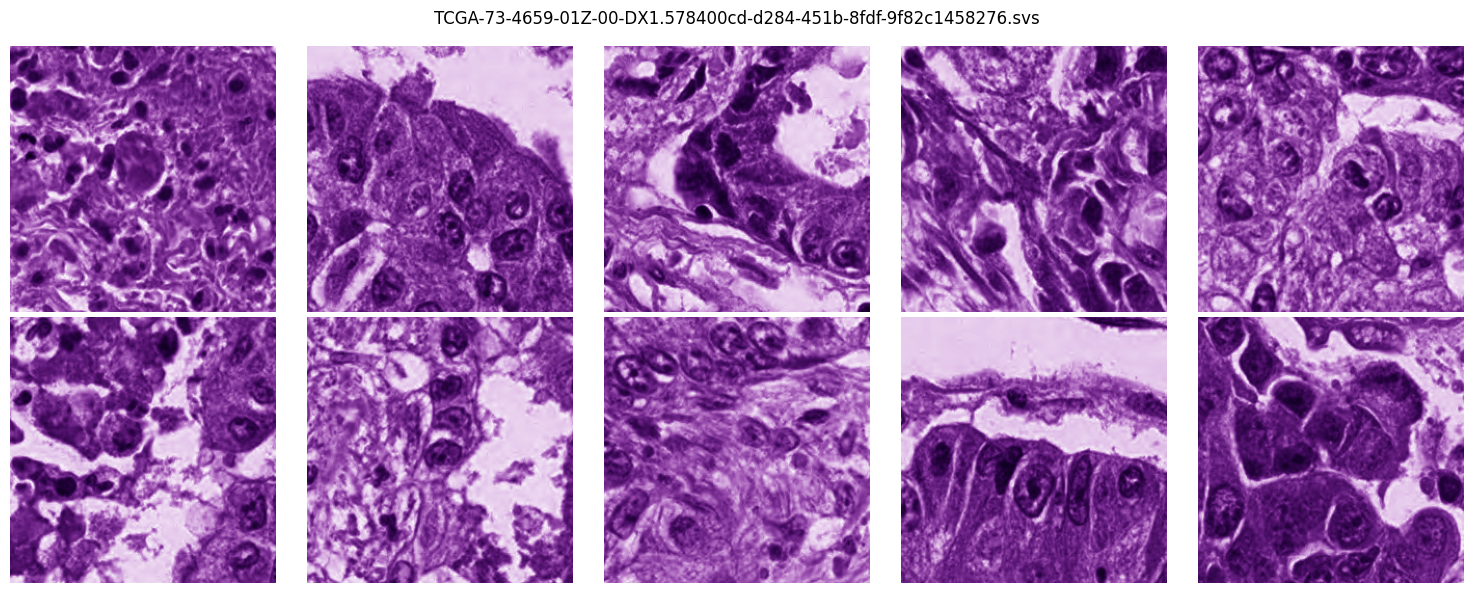

In [9]:
import matplotlib.pyplot as plt

slide_manifest = pd.read_csv(SLIDE_MANIFEST_PATH)
assert len(slide_manifest) > 0, (
    f"No slides in {SLIDE_MANIFEST_PATH} — run histopathology_data_acquisition.ipynb first."
)

row = slide_manifest.iloc[0]
print(f"Testing: {row['slide_id']}")
print(f"Path: {row['path']}")

tiles = tile_slide(row["path"], max_tiles=20)
print(f"Extracted {len(tiles)} tiles")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, (_, img) in zip(axes.flat, tiles[:10]):
    ax.imshow(img)
    ax.axis("off")
plt.suptitle(row["slide_id"])
plt.tight_layout()
plt.show()

## Step 2 — Frozen ResNet50 Tile Embeddings

ImageNet-pretrained ResNet50 (torchvision), frozen, penultimate-layer embedding
(~2048-D), batched inference on GPU (MPS on Apple Silicon). No fine-tuning — this
keeps the pipeline consistent with the project's existing scikit-learn-only
modeling pattern (fixed feature vector -> RF/LR), per plan Phase 4.3.

In [10]:
# build_resnet50_encoder() -> (frozen ResNet50 module, device)
# embed_tiles(encoder, device, tiles) -> (n_tiles, 2048) ndarray
# cache_slide_embeddings(slide_id, svs_path, TILE_CACHE_DIR, encoder, device) -> cache path

## Step 3 — Per-Patient Feature Aggregation

Mean-pooling is the baseline (not attention-MIL/CLAM, which is future work only,
per plan Phase 4.3): tile embeddings -> mean per slide -> mean across slides for
patients with multiple diagnostic slides.

**No PCA by default** — the baseline pipeline is ResNet50 -> 2048-D per-patient
embedding -> RandomForest / LogisticRegression directly. Only introduce PCA if the
feature count relative to the patient count causes overfitting/runtime issues in
practice.

In [11]:
def run_embedding_pipeline(slide_manifest: pd.DataFrame) -> None:
    """Tile + embed all slides in manifest; cache per-slide .npy embeddings."""
    encoder, device = build_resnet50_encoder()
    print(f"Embedding device: {device}")
    for i, row in slide_manifest.iterrows():
        slide_id = Path(row["slide_id"]).stem
        print(f"[{i + 1}/{len(slide_manifest)}] {row['slide_id']}")
        cache_slide_embeddings(slide_id, row["path"], TILE_CACHE_DIR, encoder, device)


slide_manifest = pd.read_csv(SLIDE_MANIFEST_PATH)
run_embedding_pipeline(slide_manifest)
features_all = aggregate_patient_features(slide_manifest, TILE_CACHE_DIR)
print(f"Patient feature matrix: {features_all.shape}")

Embedding device: mps
[1/50] TCGA-73-4659-01Z-00-DX1.578400cd-d284-451b-8fdf-9f82c1458276.svs
[2/50] TCGA-78-7158-01Z-00-DX1.74db3dcd-2715-4ce7-8e48-30c8b7946ba0.svs
[3/50] TCGA-69-A59K-01Z-00-DX1.01EAF520-9AC1-4ECC-8EF3-B9122924A1E3.svs
[4/50] TCGA-35-4122-01Z-00-DX1.2ac022e4-e796-49e5-9a24-f0ff3f76a527.svs
[5/50] TCGA-80-5611-01Z-00-DX1.31920706-8AF4-46D2-B1D4-7DD5AF4AAC77.svs
[6/50] TCGA-55-7727-01Z-00-DX1.0c7a4953-16dc-41e0-845b-b89167ec17d7.svs
[7/50] TCGA-69-7979-01Z-00-DX1.c9bc265d-4889-4333-9852-b8b535887f1e.svs
[8/50] TCGA-MP-A4T8-01Z-00-DX1.3ECB340F-66C7-4F64-8E00-463BF82AAD83.svs
[9/50] TCGA-62-A46R-01Z-00-DX1.AD823FBA-A63F-4D36-8B84-2C995DE5FC47.svs
[10/50] TCGA-MP-A4TJ-01Z-00-DX1.14EDBE5C-5D0C-4002-BE95-AF5C9D9F3D43.svs
[11/50] TCGA-99-7458-01Z-00-DX1.10ea0b2c-c763-40d1-83a4-3d4ae957fdb0.svs
[12/50] TCGA-44-3918-01Z-00-DX1.6da70a8b-6307-423a-9d2d-380c16962855.svs
[13/50] TCGA-55-A494-01Z-00-DX1.8C7C4BE0-791A-47CA-B0A8-1935366350E0.svs
[14/50] TCGA-86-8075-01Z-00-DX1.171bd8

## Step 4 — Merge with Clinical Labels, Train/Test Split

Same convention as `gene_expression_v2.ipynb` / `new_mutation_data.ipynb`: one
80/20 stratified split (stratify on OS_STATUS, random_state=42) reused across all
three targets.

In [12]:
def load_clinical():
    clinical = pd.read_csv(CLINICAL_PATH, index_col="PATIENT_ID")
    clinical["Stage"] = clinical["AJCC_PATHOLOGIC_TUMOR_STAGE"].apply(
        lambda x: int(x) if pd.notna(x) else np.nan
    )
    clinical["OS_STATUS"] = clinical["OS_STATUS"].astype(int)
    clinical["PFS_STATUS"] = clinical["PFS_STATUS"].astype(int)
    return clinical


clinical = load_clinical()
ml = features_all.join(clinical, how="inner").dropna(subset=["OS_STATUS", "PFS_STATUS", "Stage"])
embed_cols = list(features_all.columns)

train_idx, test_idx = train_test_split(
    ml.index, test_size=0.2, stratify=ml["OS_STATUS"], random_state=42
)
X_all = ml[embed_cols]
X_train, X_test = ml.loc[train_idx, embed_cols], ml.loc[test_idx, embed_cols]
print(f"Cohort for training: {len(ml)} patients (train={len(train_idx)}, test={len(test_idx)})")

Cohort for training: 45 patients (train=36, test=9)


## Step 5 — Train + Evaluate (RF / LR), Per Target

Same model family and CV discipline as Expression/Mutation: `RandomForestClassifier`
+ `LogisticRegression`, `StratifiedKFold(5)` CV on train only, honest AUC on the
locked-away test set.

In [13]:
def _cv_n_splits(y_train: pd.Series, max_splits: int = 5) -> int:
    """StratifiedKFold requires each class to appear at least n_splits times."""
    min_class = int(y_train.value_counts().min())
    if min_class < 2:
        return 0
    return min(max_splits, min_class)


def train_and_eval(X_train, y_train, X_test, y_test, label, scoring="roc_auc"):
    n_splits = _cv_n_splits(y_train)
    if n_splits >= 2:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    else:
        cv = None

    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1
        ),
        "Logistic (LASSO)": LogisticRegression(
            solver="saga", l1_ratio=1, C=0.1, random_state=42, class_weight="balanced", max_iter=5000
        ),
    }

    multiclass = scoring == "roc_auc_ovr_weighted"
    if multiclass:
        labels = np.sort(y_train.unique())
        cv_scorer = make_scorer(
            roc_auc_score,
            response_method="predict_proba",
            multi_class="ovr",
            average="weighted",
            labels=labels,
        )

    print(f"\n--- {label} ---")
    if multiclass:
        print(f"  Stage classes (train): {y_train.value_counts().sort_index().to_dict()}")
    if cv is None:
        print("  CV skipped: at least one class has fewer than 2 training samples")

    res = {}
    for name, model in models.items():
        if cv is not None:
            cv_scoring = cv_scorer if multiclass else scoring
            cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=cv_scoring)
        else:
            cv_scores = np.array([np.nan])

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)
        if multiclass:
            test_auc = roc_auc_score(
                y_test, y_prob, multi_class="ovr", average="weighted", labels=labels
            )
        else:
            test_auc = roc_auc_score(y_test, y_prob[:, 1])

        res[name] = {"cv_scores": cv_scores, "test_auc": test_auc, "model": model}
        if cv is None:
            cv_summary = "n/a (CV skipped)"
        else:
            cv_summary = f"{np.nanmean(cv_scores):.3f} +/- {np.nanstd(cv_scores):.3f}"
        print(f"  {name:<25} {cv_summary:<22}   test={test_auc:.3f}")
    return res


os_results = train_and_eval(
    X_train, ml.loc[train_idx, "OS_STATUS"], X_test, ml.loc[test_idx, "OS_STATUS"],
    "OS_STATUS — histopathology",
)
pfs_results = train_and_eval(
    X_train, ml.loc[train_idx, "PFS_STATUS"], X_test, ml.loc[test_idx, "PFS_STATUS"],
    "PFS_STATUS — histopathology",
)
stage_results = train_and_eval(
    X_train, ml.loc[train_idx, "Stage"], X_test, ml.loc[test_idx, "Stage"],
    "Stage — histopathology", scoring="roc_auc_ovr_weighted",
)


--- OS_STATUS — histopathology ---
  Random Forest             0.575 +/- 0.264          test=0.750
  Logistic (LASSO)          0.500 +/- 0.000          test=0.500

--- PFS_STATUS — histopathology ---
  Random Forest             0.667 +/- 0.192          test=0.528
  Logistic (LASSO)          0.500 +/- 0.000          test=0.500

--- Stage — histopathology ---
  Stage classes (train): {1: 17, 2: 9, 3: 9, 4: 1}
  CV skipped: at least one class has fewer than 2 training samples
  Random Forest             n/a (CV skipped)         test=0.373
  Logistic (LASSO)          n/a (CV skipped)         test=0.475


## Step 6 — Save to Feature Store

Matches the existing convention exactly:
```
Data/feature_store/histopathology/
  OS_STATUS/{features.csv, metadata.json, model.joblib, test_predictions.csv}
  PFS_STATUS/  ...
  Stage/       ...
registry_histopathology.json
```
`test_predictions.csv` is written from the start here (Expression/Mutation had to
be backfilled retroactively — see `EXP/backfill_test_predictions.py` — Histopathology
establishes the contract immediately so Phase 6 needs no backfill for this modality).

In [14]:
def save_target_to_feature_store(target, model_name, model, X_all_target, y_all, X_test, y_test, meta_extra):
    store_dir = os.path.join(FEATURE_STORE_ROOT, target)
    os.makedirs(store_dir, exist_ok=True)

    X_all_target.to_csv(os.path.join(store_dir, "features.csv"))
    joblib.dump(model, os.path.join(store_dir, "model.joblib"))

    proba = model.predict_proba(X_test)
    pred = model.predict(X_test)
    if target == "Stage":
        out = pd.DataFrame({"patient_id": X_test.index, "true_label": y_test.values, "predicted_label": pred})
        for i, cls in enumerate(model.classes_):
            out[f"probability_class_{int(cls)}"] = proba[:, i]
    else:
        out = pd.DataFrame(
            {
                "patient_id": X_test.index,
                "true_label": y_test.values,
                "predicted_label": pred,
                "predicted_probability": proba[:, 1],
            }
        )
    out.to_csv(os.path.join(store_dir, "test_predictions.csv"), index=False)

    meta = {
        "target": target,
        "model_type": model_name,
        "n_features": X_all_target.shape[1],
        "created": str(date.today()),
        **meta_extra,
    }
    with open(os.path.join(store_dir, "metadata.json"), "w") as f:
        json.dump(meta, f, indent=2)
    return meta


registry = {}
for target, results in {
    "OS_STATUS": os_results,
    "PFS_STATUS": pfs_results,
    "Stage": stage_results,
}.items():
    best_name = max(results, key=lambda k: results[k]["test_auc"])
    best = results[best_name]
    meta = save_target_to_feature_store(
        target,
        best_name,
        best["model"],
        X_all,
        ml[target],
        X_test,
        ml.loc[test_idx, target],
        meta_extra={
            "cv_auc_mean": round(float(best["cv_scores"].mean()), 4),
            "cv_auc_std": round(float(best["cv_scores"].std()), 4),
            "test_auc": round(float(best["test_auc"]), 4),
            "train_patients": len(train_idx),
            "test_patients": len(test_idx),
            "total_patients": len(ml),
        },
    )
    registry[target] = meta

with open(REGISTRY_PATH, "w") as f:
    json.dump(registry, f, indent=2)

print(f"Saved feature store to {FEATURE_STORE_ROOT}")
print(f"Registry: {REGISTRY_PATH}")

Saved feature store to /Users/soumoha2/Documents/BITS/ONCOLENS/Data/feature_store/histopathology
Registry: /Users/soumoha2/Documents/BITS/ONCOLENS/Data/feature_store/registry_histopathology.json
